# Task 4: Customer Churn & Retention Analysis

This task focuses on analyzing customer churn behavior, identifying high-risk customer groups, and developing practical retention recommendations based on data-driven evidence.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
from google.colab import files

uploaded = files.upload()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv


In [4]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
print("Dataset Shape:", df.shape)
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())

Dataset Shape: (7043, 21)

Data Types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Missing Values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract    

In [6]:
# Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check missing values created after conversion
print("Missing values in TotalCharges:", df['TotalCharges'].isnull().sum())

Missing values in TotalCharges: 11


In [7]:
df[df['TotalCharges'].isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [8]:
# Fill missing TotalCharges for customers with 0 months of tenure
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Verify that no missing values remain
print("Missing values after cleaning:", df['TotalCharges'].isnull().sum())

Missing values after cleaning: 0


In [9]:
print(df['TotalCharges'].dtype)

float64


## 3. Churn Analysis

Customer churn is analyzed to determine the overall proportion of customers who left the company compared with those who remained. This provides a baseline for the detailed churn analysis that follows.

In [10]:
# Overall churn analysis

total_customers = len(df)
churned_customers = (df['Churn'] == 'Yes').sum()
retained_customers = (df['Churn'] == 'No').sum()
churn_rate = (churned_customers / total_customers) * 100

print("Total Customers:", total_customers)
print("Churned Customers:", churned_customers)
print("Retained Customers:", retained_customers)
print("Churn Rate: {:.2f}%".format(churn_rate))

Total Customers: 7043
Churned Customers: 1869
Retained Customers: 5174
Churn Rate: 26.54%


The dataset contains 7,043 customers, of which 1,869 customers have churned while 5,174 customers have been retained. The overall churn rate is 26.54%, meaning approximately one out of every four customers has left the company.

In [11]:
# Churn rate by contract type

contract_churn = pd.crosstab(
    df['Contract'],
    df['Churn'],
    normalize='index'
) * 100

contract_churn

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


In [12]:
contract_churn_rate = (
    df.groupby('Contract')['Churn']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .sort_values(ascending=False)
)

print("Churn Rate by Contract:")
print(contract_churn_rate)

Churn Rate by Contract:
Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: Churn, dtype: float64


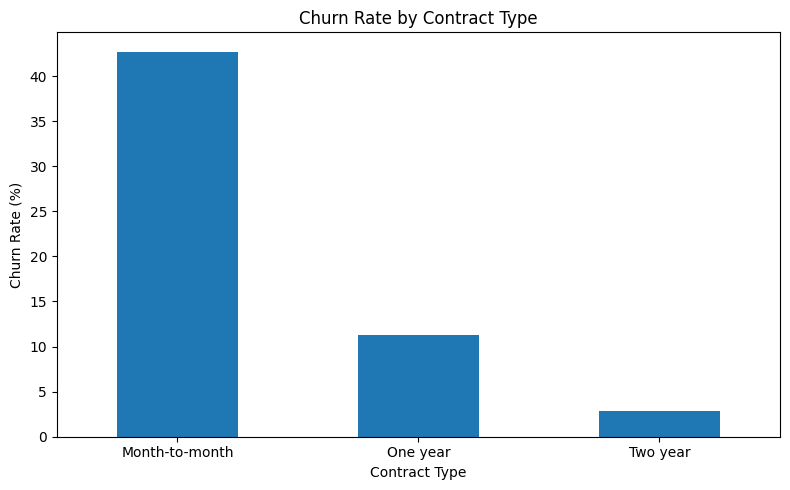

In [13]:
plt.figure(figsize=(8, 5))

contract_churn_rate.plot(kind='bar')

plt.title('Churn Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Interpretation:** Month-to-month customers have the highest churn rate at 42.71%, compared with 11.27% for one-year contracts and only 2.83% for two-year contracts. This indicates that customers with shorter contract commitments are substantially more likely to leave.

In [14]:
# Create tenure groups

bins = [-1, 12, 24, 48, np.inf]
labels = ['0–12 months', '13–24 months', '25–48 months', '49+ months']

df['TenureGroup'] = pd.cut(
    df['tenure'],
    bins=bins,
    labels=labels
)

# Calculate churn rate by tenure group
tenure_churn_rate = (
    df.groupby('TenureGroup', observed=True)['Churn']
    .apply(lambda x: (x == 'Yes').mean() * 100)
)

print("Churn Rate by Tenure Group:")
print(tenure_churn_rate)

Churn Rate by Tenure Group:
TenureGroup
0–12 months     47.438243
13–24 months    28.710938
25–48 months    20.388959
49+ months       9.513176
Name: Churn, dtype: float64


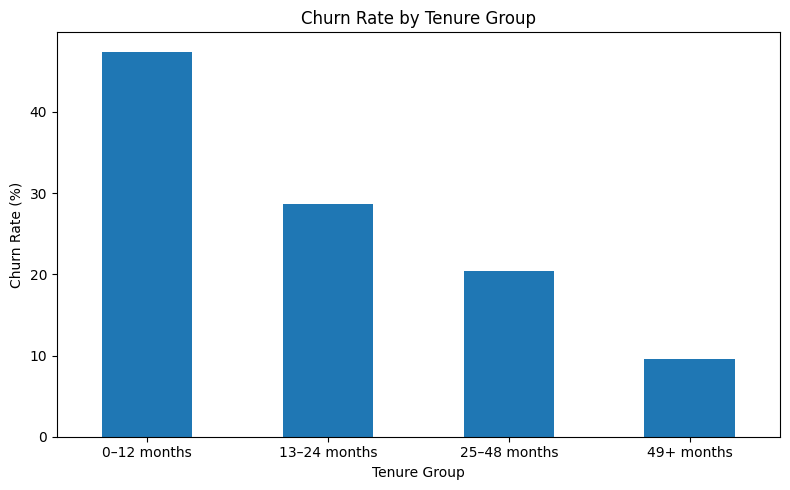

In [15]:
plt.figure(figsize=(8, 5))

tenure_churn_rate.plot(kind='bar')

plt.title('Churn Rate by Tenure Group')
plt.xlabel('Tenure Group')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [16]:
monthly_charges_comparison = df.groupby('Churn')['MonthlyCharges'].mean()

print("Average Monthly Charges:")
print(monthly_charges_comparison)

Average Monthly Charges:
Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64


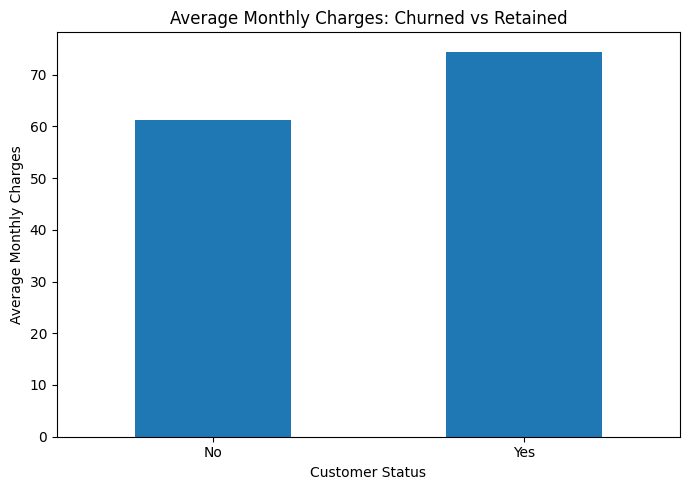

In [17]:
plt.figure(figsize=(7, 5))

monthly_charges_comparison.plot(kind='bar')

plt.title('Average Monthly Charges: Churned vs Retained')
plt.xlabel('Customer Status')
plt.ylabel('Average Monthly Charges')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Interpretation:** Churned customers have a higher average monthly charge of 74.44 compared with 61.27 for retained customers. This indicates that customers paying higher monthly charges show a greater tendency to churn.


In [18]:
payment_churn_rate = (
    df.groupby('PaymentMethod')['Churn']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .sort_values(ascending=False)
)

print("Churn Rate by Payment Method:")
print(payment_churn_rate)

Churn Rate by Payment Method:
PaymentMethod
Electronic check             45.285412
Mailed check                 19.106700
Bank transfer (automatic)    16.709845
Credit card (automatic)      15.243101
Name: Churn, dtype: float64


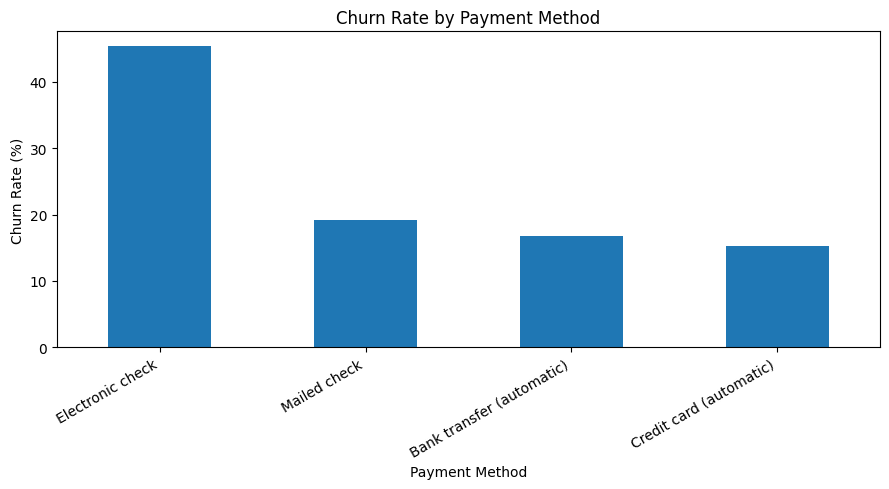

In [19]:
plt.figure(figsize=(9, 5))

payment_churn_rate.plot(kind='bar')

plt.title('Churn Rate by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

**Interpretation:** Customers using **Electronic check** have the highest churn rate at **45.29%**, while customers using automatic bank transfer and credit card payments have much lower churn rates of 16.71% and 15.24%, respectively. This shows a strong difference in churn behavior across payment methods, with electronic check customers representing a higher-risk group.


In [20]:
internet_churn_rate = (
    df.groupby('InternetService')['Churn']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .sort_values(ascending=False)
)

print("Churn Rate by Internet Service:")
print(internet_churn_rate)

Churn Rate by Internet Service:
InternetService
Fiber optic    41.892765
DSL            18.959108
No              7.404980
Name: Churn, dtype: float64


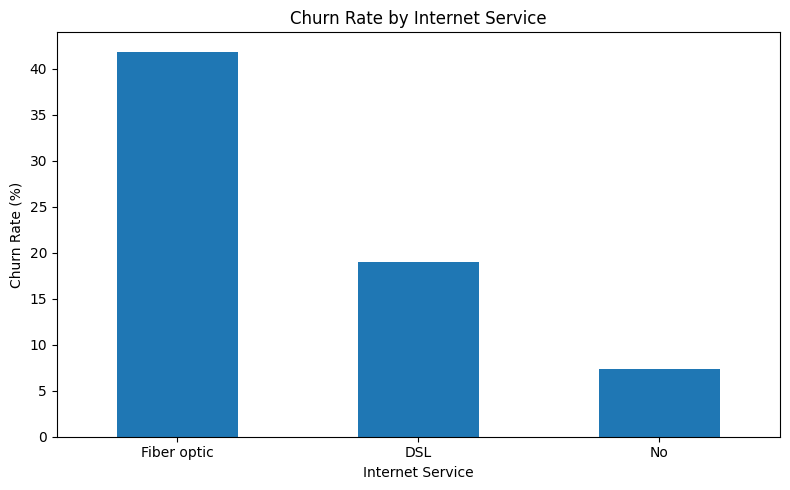

In [21]:
plt.figure(figsize=(8, 5))

internet_churn_rate.plot(kind='bar')

plt.title('Churn Rate by Internet Service')
plt.xlabel('Internet Service')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Interpretation:** Customers using **Fiber optic** service have the highest churn rate at **41.89%**, compared with 18.96% for DSL customers and only 7.40% for customers without internet service. This shows that Fiber optic customers represent a higher-churn group in the dataset.


In [22]:
security_churn_rate = (
    df.groupby('OnlineSecurity')['Churn']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .sort_values(ascending=False)
)

print("Churn Rate by Online Security:")
print(security_churn_rate)

Churn Rate by Online Security:
OnlineSecurity
No                     41.766724
Yes                    14.611194
No internet service     7.404980
Name: Churn, dtype: float64


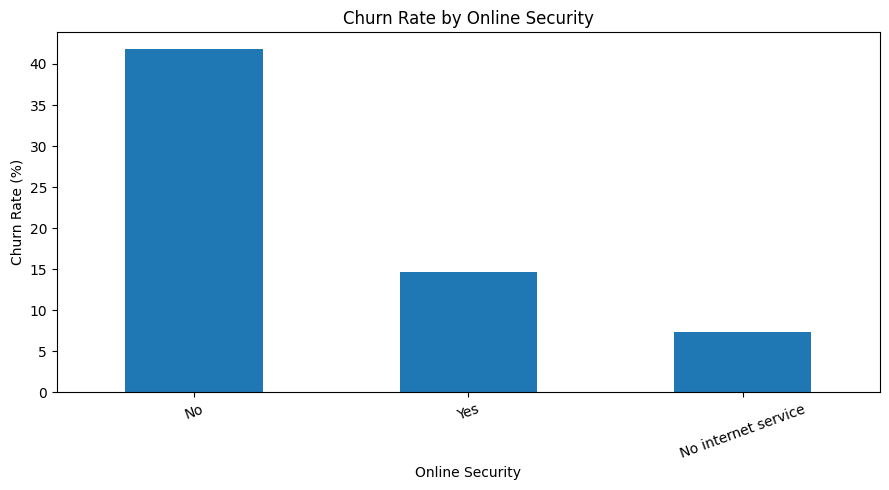

In [23]:
plt.figure(figsize=(9, 5))

security_churn_rate.plot(kind='bar')

plt.title('Churn Rate by Online Security')
plt.xlabel('Online Security')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

**Interpretation:** Customers without Online Security have a much higher churn rate of **41.77%**, compared with **14.61%** for customers who have Online Security. Customers with no internet service have the lowest churn rate at **7.40%**. This indicates that customers without Online Security represent a higher-churn group.


In [24]:
from scipy.stats import chi2_contingency

contract_churn_table = pd.crosstab(df['Contract'], df['Churn'])

chi2, p_value, dof, expected = chi2_contingency(contract_churn_table)

print("Chi-Square Statistic:", chi2)
print("p-value:", p_value)
print("Degrees of Freedom:", dof)

if p_value < 0.05:
    print("Result: Significant relationship between Contract and Churn.")
else:
    print("Result: No significant relationship between Contract and Churn.")

Chi-Square Statistic: 1184.5965720837926
p-value: 5.863038300673391e-258
Degrees of Freedom: 2
Result: Significant relationship between Contract and Churn.


**Interpretation:** The Chi-Square test produced a p-value far below the significance level of 0.05. Therefore, the null hypothesis is rejected, indicating a statistically significant relationship between contract type and customer churn. This supports the earlier analysis showing that month-to-month customers have substantially higher churn than customers with longer-term contracts.


In [25]:
from scipy.stats import ttest_ind

churned_charges = df[df['Churn'] == 'Yes']['MonthlyCharges']
retained_charges = df[df['Churn'] == 'No']['MonthlyCharges']

t_stat, p_value = ttest_ind(churned_charges, retained_charges)

print("T-Statistic:", t_stat)
print("p-value:", p_value)

if p_value < 0.05:
    print("Result: Significant difference in Monthly Charges between churned and retained customers.")
else:
    print("Result: No significant difference in Monthly Charges between churned and retained customers.")

T-Statistic: 16.536738015936308
p-value: 2.7066456068884154e-60
Result: Significant difference in Monthly Charges between churned and retained customers.


**Interpretation:** The Independent Samples T-Test produced a p-value far below the significance level of 0.05. Therefore, the null hypothesis was rejected, indicating a statistically significant difference in Monthly Charges between churned and retained customers. Churned customers also had a higher average monthly charge (74.44) than retained customers (61.27).


In [26]:
avg_monthly_charge = df['MonthlyCharges'].mean()

def assign_segment(row):
    if row['Churn'] == 'Yes':
        return 'High-Risk'
    elif row['tenure'] <= 12:
        return 'New'
    elif row['MonthlyCharges'] >= avg_monthly_charge:
        return 'High-Value'
    else:
        return 'Loyal'

df['CustomerSegment'] = df.apply(assign_segment, axis=1)

print("Overall Average Monthly Charges:", round(avg_monthly_charge, 2))
print("\nCustomer Segment Counts:")
print(df['CustomerSegment'].value_counts())

Overall Average Monthly Charges: 64.76

Customer Segment Counts:
CustomerSegment
High-Value    2227
High-Risk     1869
Loyal         1798
New           1149
Name: count, dtype: int64


In [27]:
segment_analysis = df.groupby('CustomerSegment').agg(
    Customer_Count=('customerID', 'count'),
    Average_Tenure=('tenure', 'mean'),
    Average_Monthly_Charges=('MonthlyCharges', 'mean'),
    Churn_Rate=('Churn', lambda x: (x == 'Yes').mean() * 100)
).round(2)

segment_analysis

,Customer_Count,Average_Tenure,Average_Monthly_Charges,Churn_Rate
CustomerSegment,,,,
High-Risk,1869,17.98,74.44,100.0
High-Value,2227,50.17,90.23,0.0
Loyal,1798,42.53,34.69,0.0
New,1149,5.39,46.71,0.0


**Interpretation:** The segmentation divides the customers into four rule-based groups: High-Risk, High-Value, Loyal, and New. The High-Risk segment contains 1,869 churned customers and has the highest average monthly charge of 74.44 among the churned group. The High-Value segment contains 2,227 customers with an average tenure of 50.17 months and average monthly charges of 90.23. The New segment contains 1,149 customers with an average tenure of 5.39 months. Since the High-Risk segment consists of customers who have already churned, it represents the group requiring the most attention for retention analysis.


In [28]:
revenue_at_risk = df.loc[df['Churn'] == 'Yes', 'MonthlyCharges'].sum()

print("Monthly Revenue at Risk:", round(revenue_at_risk, 2))

Monthly Revenue at Risk: 139130.85


**Interpretation:** The Monthly Revenue at Risk is **139,130.85**, calculated as the total Monthly Charges of all churned customers. This represents the estimated recurring monthly revenue associated with customers who have already left the company, highlighting the financial impact of customer churn.


In [30]:
df.to_csv('Task4_Churn_Analysis_Data.csv', index=False)

print("Updated CSV saved successfully!")
print("Shape:", df.shape)

Updated CSV saved successfully!
Shape: (7043, 23)


In [31]:
from google.colab import files
files.download('Task4_Churn_Analysis_Data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>